In [1]:
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt

In [2]:
## Get the number of occurence of each resistance genes

sparqlQuery = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT
    ?gene_name
    (SUM(IF(?sampleTypeLabel = "human", 1, 0)) AS ?human_count)
    (SUM(IF(?sampleTypeLabel = "animal", 1, 0)) AS ?animal_count)
    (SUM(IF(?sampleTypeLabel = "environmental", 1, 0)) AS ?environmental_count)
    (COUNT(*) AS ?total_count)
FROM <http://www.ontotext.com/explicit>
WHERE {
    ?sample rdf:type sio:001050 ;
            sio:000068 ?sampleType .

    ?sampleType rdfs:label ?sampleTypeLabel .

    FILTER(?sampleTypeLabel IN ("human", "animal", "environmental"))

    ?observableProperty rdf:type sosa:ObservableProperty ;
                        rdfs:label "Resistance gene" .

    ?observation sosa:observedProperty ?observableProperty ;
                 sio:000332 ?sample ;
                 sosa:hasFeatureOfInterest ?gene .

    ?gene rdf:type ncit:C16612 ;
          rdf:type [ rdfs:subClassOf+ aro:3000000 ] ;
          rdfs:label ?gene_name .
}
GROUP BY ?gene_name
ORDER BY DESC(?total_count)
"""

In [3]:
## Defining a data structure for the plot
data = {
    "gene_name": [],
    "animal_count": [],
    "environmental_count": [],
    "human_count": [],
    "total_count": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("https://10-54-3-233.gcp.glicid.fr/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery)
try:
    res = sparql.query().convert()
    recs = res["results"]["bindings"]
    for item in recs:
        data["gene_name"].append(item["gene_name"]["value"])
        data["animal_count"].append(int(item["animal_count"]["value"]))
        data["environmental_count"].append(int(item["environmental_count"]["value"]))
        data["human_count"].append(int(item["human_count"]["value"]))
        data["total_count"].append(int(item["total_count"]["value"]))
except Exception as e:
    print(e)

In [4]:
df = pd.DataFrame(data)
df

,gene_name,animal_count,environmental_count,human_count,total_count
0,ADC-25,40,36,7,83
1,sul1,18,7,2,27
2,sul2,18,6,2,26
3,floR,16,3,1,20
4,ant(2'')-Ia,12,6,0,18
...,...,...,...,...,...
125,catB8,0,1,0,1
126,cfxA3,0,1,0,1
127,mcr-3.10,0,1,0,1
128,aac(6')-Ib-Hangzhou,0,1,0,1


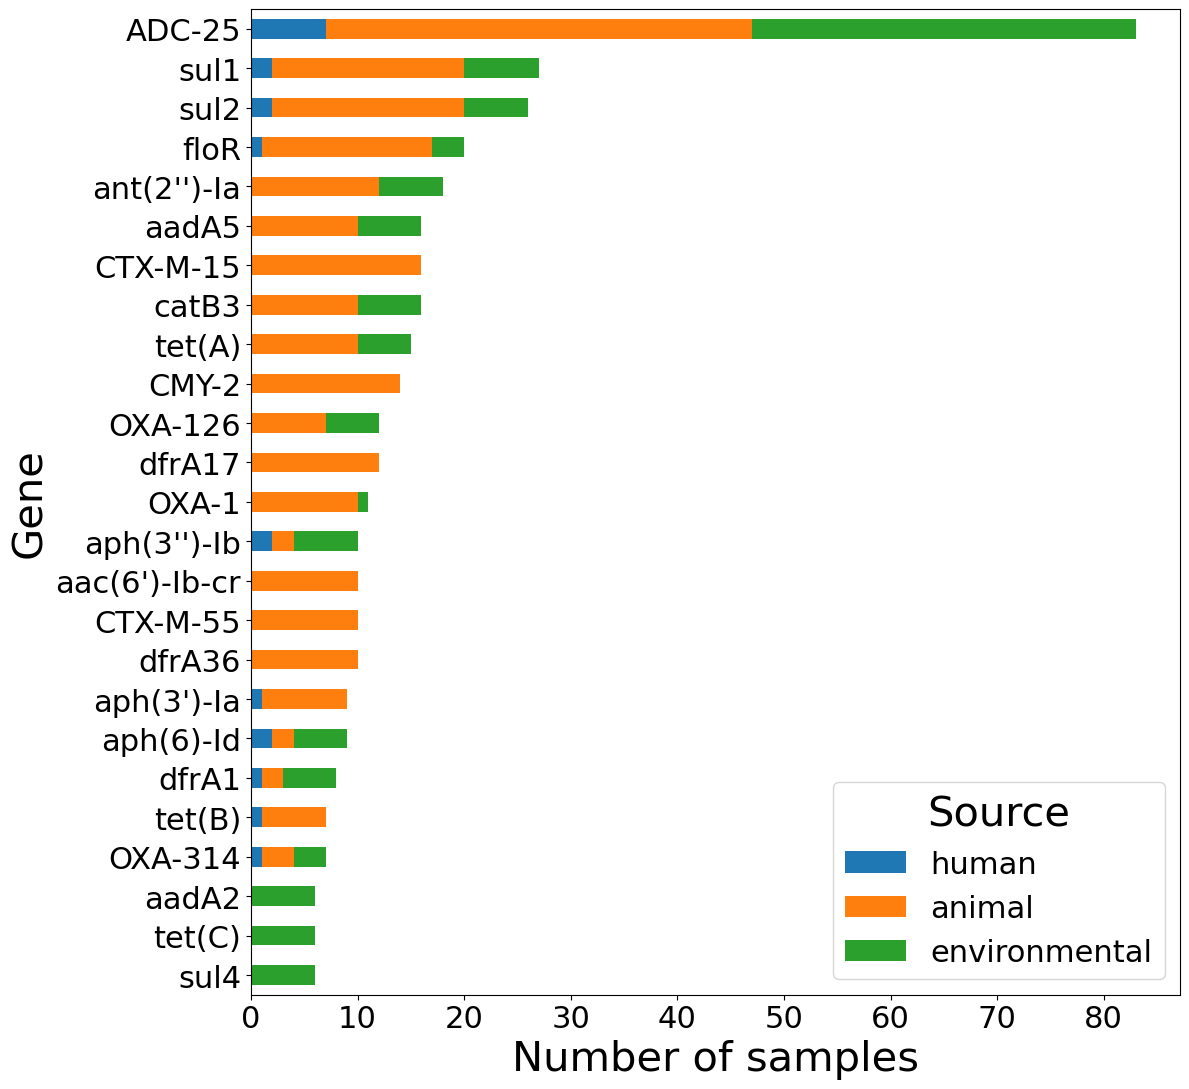

In [5]:
# default style forces white background + black text, even if a dark theme
# was activated earlier in the kernel
with plt.style.context("default"):
    df = df.sort_values("total_count")

    top50 = df.nlargest(25, "total_count").sort_values("total_count")

    ax = top50.set_index("gene_name")[
        ["human_count", "animal_count", "environmental_count"]
    ].rename(columns={
        "human_count": "human",
        "animal_count": "animal",
        "environmental_count": "environmental",
    }).plot(
        kind="barh",
        stacked=True,
        figsize=(12, 11)
    )

    ## larger fonts for readability
    ax.set_xlabel("Number of samples", fontsize=30)
    ax.set_ylabel("Gene", fontsize=30)
    ax.tick_params(axis="both", labelsize=22)
    ## plt.title("Resistance genes by sample source")
    ax.legend(title="Source", fontsize=22, title_fontsize=30)
    plt.tight_layout()
    plt.savefig("figure2-c.png", dpi=600, facecolor="white", bbox_inches="tight")
    plt.savefig("figure2-c.pdf", facecolor="white", bbox_inches="tight")
    plt.show()

In [6]:
## Get the number of samples having each number of a resistance genes

sparqlQuery2 = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?geneCount (COUNT(?sample) AS ?sampleCount)
FROM <http://www.ontotext.com/explicit>
WHERE {
  {
    SELECT ?sample (COUNT(DISTINCT ?gene) AS ?geneCount)
    WHERE {
      ?sample rdf:type sio:001050 .

    ?observableProperty rdf:type sosa:ObservableProperty ;
        rdfs:label 'Resistance gene' .

    ?observation sosa:observedProperty ?observableProperty ;
        sio:000332 ?sample ;
        sosa:hasFeatureOfInterest ?gene .

    ?gene rdf:type ncit:C16612 ;
          rdf:type [ rdfs:subClassOf+ aro:3000000 ] ;
        rdfs:label ?gene_name .
    }
    GROUP BY ?sample
  }
}
GROUP BY ?geneCount
ORDER BY ?geneCount
"""

In [7]:
## Defining a data structure for the plot
data2 = {
    "geneCount": [],
    "sampleCount": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("https://10-54-3-233.gcp.glicid.fr/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery2)
try:
    res2 = sparql.query().convert()
    recs2 = res2["results"]["bindings"]
    for item in recs2:
        data2["geneCount"].append(item["geneCount"]["value"])
        data2["sampleCount"].append(int(item["sampleCount"]["value"]))
except Exception as e:
    print(e)

In [8]:
df2 = pd.DataFrame(data2)
df2

,geneCount,sampleCount
0,1,4
1,2,82
2,3,1
3,4,1
4,5,1
5,6,4
6,7,1
7,8,2
8,10,1
9,11,6


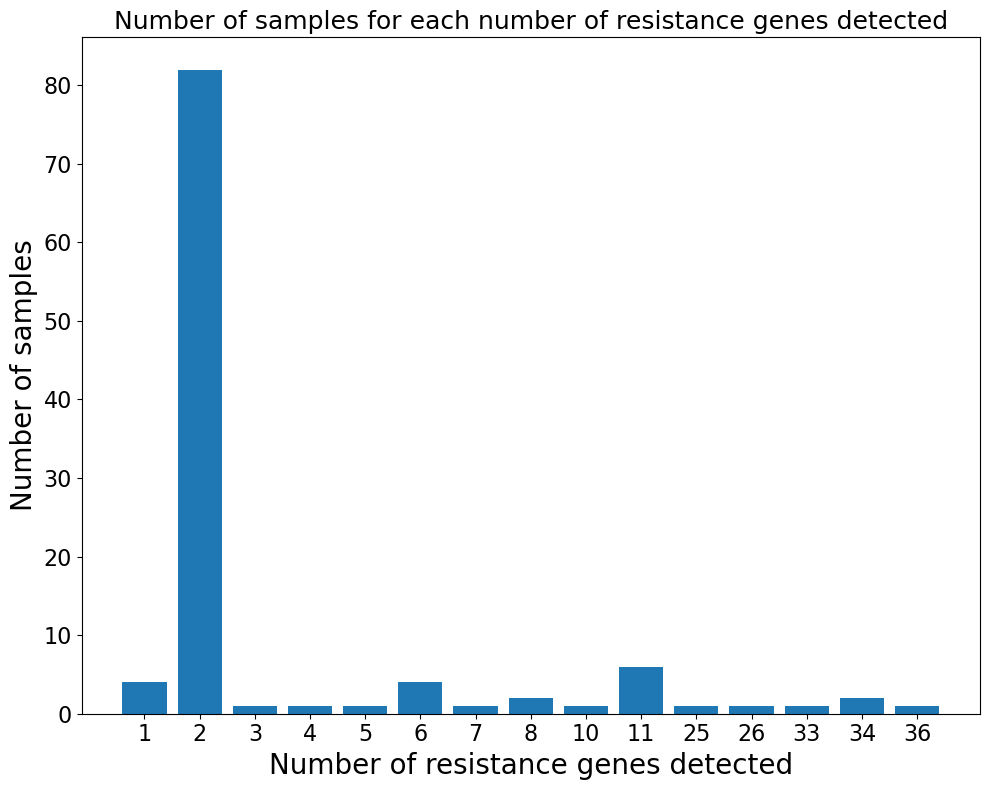

In [9]:
with plt.style.context("default"):
    plt.figure(figsize=(10, 8))
    plt.bar(df2["geneCount"], df2["sampleCount"])
    plt.xlabel("Number of resistance genes detected", fontsize=20)
    plt.ylabel("Number of samples", fontsize=20)
    plt.title("Number of samples for each number of resistance genes detected",
              fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.show()